In [36]:
import os
os.chdir(os.getcwd())

In [37]:
import pandas as pd
from joblib import load
from sklearn.metrics import f1_score,confusion_matrix, classification_report, ConfusionMatrixDisplay
import numpy as np
import matplotlib.pyplot as plt

In [38]:
oxide = pd.read_excel("oxide_data.xlsx", sheet_name="Sheet1",index_col=0,header=0)

In [39]:
def wt_to_mol(data, oxide = oxide):
    data[data<=2] = 0
    if 'Total' in data.columns:
        data.pop('Total')
    oxlist1 = data.columns
    oxide = oxide.T[oxlist1].iloc[0, :]
    data = normalize(data,100)
    data_f = data.div(oxide,axis=1)
    data_f = normalize(data_f)
    return(data_f.round(2))

In [40]:
def normalize(data,n=100):
    s = n/data.sum(axis=1)
    data_formatted = data.mul(s,axis=0)
    return(data_formatted)

# Read the test dataset and create accuracy table

In [41]:
file_test = r"Validation data.xlsx"

# data = pd.read_excel(file,header=0,index_col=0)
data_test = pd.read_excel(file_test,header=0,index_col=0)
m = len(data_test['Mineral'].unique())
acc_table = np.zeros((m+1,4))

In [42]:
if 'Mineral' in data_test.columns:
    minerals = data_test.pop("Mineral")
if 'Source' in data_test.columns:
    source = data_test.pop("Source")
if 'F' in data_test.columns:
    data_test.pop('F')
if 'Cl' in data_test.columns:
    data_test.pop('Cl')

data_test = normalize(data_test)
metrics = 'macro'
samplemetrics = 'micro'
if 'Total' not in data_test.columns:
    data_test['Total'] = data_test.iloc[:,:-2].sum(axis=1)

In [43]:
data_test.fillna(0,inplace=True)
data_test_original = data_test.copy()
data_test = data_test.round(2)

In [44]:
data_test = wt_to_mol(data_test,oxide)

# Raw Input (C1)

In [45]:
model = load("SVM_C1.mdl")
scaler = load("Scaler_SVM_C1.scl")
labeler = load("Labeler_SVM_C1.lbl")

data_test1 = data_test.copy()
colnames_raw = ['SiO2','TiO2','Al2O3','FeO','MnO','MgO','CaO','Na2O','K2O','P2O5','CO2']
data_test1 = normalize(data_test1[colnames_raw])

data_test_scaled = scaler.transform(data_test1)
test_target = labeler.transform(minerals)
pred_label = model.predict(data_test_scaled)
a = round(f1_score(test_target, pred_label, average=metrics,zero_division=0),4)*100
acc_table[0,0] = a
print("Overall: "+str(a))

labels = labeler.transform(minerals.unique())
labels1 = labeler.inverse_transform(labels)

for n,i in enumerate(labels1):
    data_test2 = scaler.transform(data_test1.loc[minerals==i,:])
    minerals2 = labeler.transform(minerals.loc[minerals == i])
    pred_label2 = model.predict(data_test2)
    a = round(f1_score(minerals2, pred_label2, average=samplemetrics,zero_division=0),4)*100
    acc_table[n+1,0] = a

    print(labels1[n]+": "+str(round(a,2)))

data_mismatch = data_test.loc[test_target != pred_label,:]
minerals_mismatch = minerals.loc[test_target != pred_label]
data_mismatch = pd.concat([data_mismatch,minerals_mismatch],axis=1)
data_mismatch
f1_c1 = f1_score(minerals, labeler.inverse_transform(pred_label),average=None)

Overall: 91.28
Amp: 99.01
Ap: 100.0
Bt: 100.0
Crd: 100.0
Fsp: 84.35
Grt: 99.69
Ilm: 98.41
Mag/Hem: 100.0
Ms: 100.0
Ol: 99.08
Px: 94.76
Spl: 86.21
St: 100.0
Ttn: 100.0
Als: 100.0
Cb: 94.87
Qz: 100.0
Rt: 100.0


In [46]:
print(classification_report(labeler.inverse_transform(test_target),labeler.inverse_transform(pred_label)))

              precision    recall  f1-score   support

         Als       1.00      1.00      1.00        10
         Amp       0.89      0.99      0.94       203
          Ap       1.00      1.00      1.00       136
          Bt       1.00      1.00      1.00       548
          Cb       1.00      0.95      0.97        39
         Cor       0.00      0.00      0.00         0
         Crd       1.00      1.00      1.00       157
         Fsp       1.00      0.84      0.92       428
         Grt       0.99      1.00      1.00       326
         Ilm       0.97      0.98      0.98       126
     Mag/Hem       0.97      1.00      0.99        78
          Ms       0.51      1.00      0.67        60
          Ol       1.00      0.99      1.00       217
          Px       0.98      0.95      0.96       458
          Qz       1.00      1.00      1.00         2
          Rt       1.00      1.00      1.00         4
         Spl       1.00      0.86      0.93        58
          St       1.00    

C:\Users\naik3\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\naik3\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\naik3\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, le

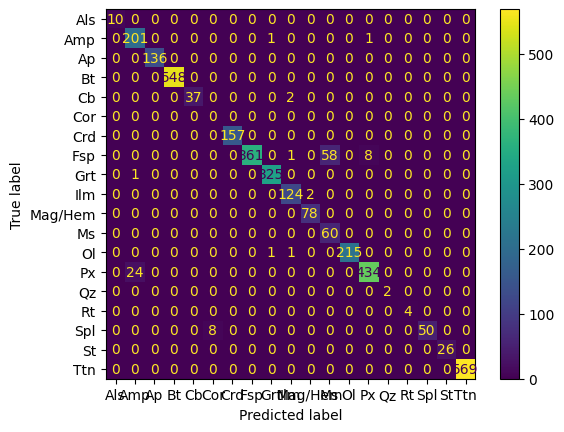

In [47]:
ConfusionMatrixDisplay.from_predictions(labeler.inverse_transform(test_target),labeler.inverse_transform(pred_label))

In [48]:
if 'SrO' in data_test.columns:
    data_test['CaO'] = data_test['CaO'] + data_test['SrO']
    data_test.pop('SrO')
if 'BaO' in data_test.columns:
    data_test['CaO'] = data_test['CaO'] + data_test['BaO']
    data_test.pop('BaO')
if 'Cr2O3' in data_test.columns:
    data_test['Al2O3'] = data_test['Al2O3'] + data_test['Cr2O3']
    data_test.pop('Cr2O3')
if 'ZnO' in data_test.columns:
    data_test['FeO'] = data_test['FeO'] + data_test['ZnO']
    data_test.pop('ZnO')
if 'CoO' in data_test.columns:
    data_test['FeO'] = data_test['FeO'] + data_test['CoO']
    data_test.pop('CoO')
if 'Fe2O3' in data_test.columns:
    data_test['Al2O3'] = data_test['Al2O3'] + data_test['Fe2O3']
    data_test.pop('Fe2O3')

# C2

In [49]:
model = load("SVM_C2.mdl")
scaler = load("Scaler_SVM_C2.scl")
labeler = load("Labeler_SVM_C2.lbl")

data_test1 = data_test.copy()
data_test1['M'] = data_test1[["FeO","MnO","MgO"]].sum(axis=1)
data_test1 = normalize(data_test1[['SiO2','TiO2','Al2O3','M','CaO','Na2O','K2O','P2O5','CO2']])

data_test_scaled = scaler.transform(data_test1)
test_target = labeler.transform(minerals)
pred_label = model.predict(data_test_scaled)
a = round(f1_score(test_target, pred_label, average=metrics,zero_division=0),4)*100
acc_table[0,1] = a
print("Overall: "+str(a))

labels = labeler.transform(minerals.unique())
labels1 = labeler.inverse_transform(labels)

for n,i in enumerate(labels1):
    data_test2 = scaler.transform(data_test1.loc[minerals==i,:])
    minerals2 = labeler.transform(minerals.loc[minerals == i])
    pred_label2 = model.predict(data_test2)
    a = round(f1_score(minerals2, pred_label2, average=samplemetrics,zero_division=0),4)*100
    acc_table[n+1,1] = a
    print(labels1[n]+": "+str(round(a,2)))

data_mismatch = data_test.loc[test_target != pred_label,:]
minerals_mismatch = minerals.loc[test_target != pred_label]
data_mismatch = pd.concat([data_mismatch,minerals_mismatch],axis=1)
f1_c2 = f1_score(minerals, labeler.inverse_transform(pred_label),average=None)

Overall: 97.21
Amp: 98.52
Ap: 100.0
Bt: 100.0
Crd: 100.0
Fsp: 85.05
Grt: 100.0
Ilm: 100.0
Mag/Hem: 100.0
Ms: 100.0
Ol: 100.0
Px: 95.2
Spl: 100.0
St: 100.0
Ttn: 100.0
Als: 100.0
Cb: 100.0
Qz: 100.0
Rt: 100.0


In [50]:
print(classification_report(labeler.inverse_transform(test_target),labeler.inverse_transform(pred_label)))

              precision    recall  f1-score   support

         Als       1.00      1.00      1.00        10
         Amp       0.90      0.99      0.94       203
          Ap       1.00      1.00      1.00       136
          Bt       1.00      1.00      1.00       548
          Cb       1.00      1.00      1.00        39
         Crd       1.00      1.00      1.00       157
         Fsp       1.00      0.85      0.92       428
         Grt       1.00      1.00      1.00       326
         Ilm       1.00      1.00      1.00       126
     Mag/Hem       1.00      1.00      1.00        78
          Ms       0.50      1.00      0.67        60
          Ol       1.00      1.00      1.00       217
          Px       0.98      0.95      0.97       458
          Qz       1.00      1.00      1.00         2
          Rt       1.00      1.00      1.00         4
         Spl       1.00      1.00      1.00        58
          St       1.00      1.00      1.00        26
         Ttn       1.00    

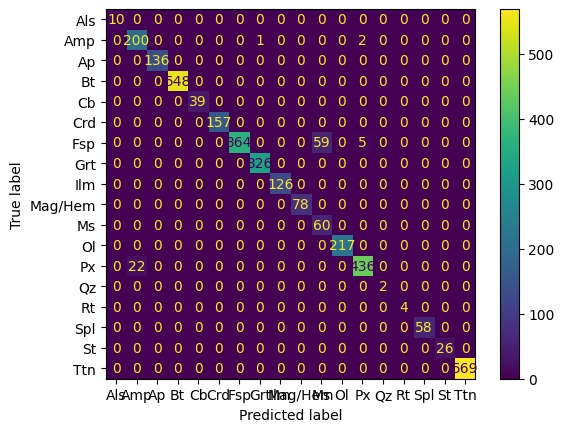

In [51]:
ConfusionMatrixDisplay.from_predictions(labeler.inverse_transform(test_target),labeler.inverse_transform(pred_label))

# C3

In [52]:
model = load("SVM_C3.mdl")
scaler = load("Scaler_SVM_C3.scl")
labeler = load("Labeler_SVM_C3.lbl")

data_test1 = data_test.copy()
data_test1['M'] = data_test1[["FeO","MnO","MgO"]].sum(axis=1)
data_test1['A'] = data_test1[["Na2O","K2O"]].sum(axis=1)
colnames = ['SiO2','TiO2','Al2O3','M','CaO','A','P2O5','CO2']
data_test1 = normalize(data_test1[colnames])

data_test_scaled = scaler.transform(data_test1)
test_target = labeler.transform(minerals)
pred_label = model.predict(data_test_scaled)
a = round(f1_score(test_target, pred_label, average=metrics,zero_division=0),4)*100
acc_table[0,2] = a
print("Overall: "+str(a))

labels = labeler.transform(minerals.unique())
labels1 = labeler.inverse_transform(labels)

for n,i in enumerate(labels1):
    data_test2 = scaler.transform(data_test1.loc[minerals==i,:])
    minerals2 = labeler.transform(minerals.loc[minerals == i])
    pred_label2 = model.predict(data_test2)
    a = round(f1_score(minerals2, pred_label2, average=samplemetrics,zero_division=0),4)*100
    acc_table[n+1,2] = a
    print(labels1[n]+": "+str(round(a,2)))

data_mismatch = data_test.loc[test_target != pred_label,:]
data_mismatch1 = data_test_original.loc[test_target != pred_label,:]
minerals_mismatch = minerals.loc[test_target != pred_label]
data_mismatch = pd.concat([data_mismatch1,minerals_mismatch],axis=1)
data_mismatch['Source'] = source.loc[test_target != pred_label]
f1_c3 = f1_score(minerals, labeler.inverse_transform(pred_label),average=None)

Overall: 99.53999999999999
Amp: 99.01
Ap: 100.0
Bt: 100.0
Crd: 100.0
Fsp: 100.0
Grt: 100.0
Ilm: 100.0
Mag/Hem: 100.0
Ms: 100.0
Ol: 100.0
Px: 95.2
Spl: 100.0
St: 100.0
Ttn: 100.0
Als: 100.0
Cb: 100.0
Qz: 100.0
Rt: 100.0


In [53]:
print(classification_report(labeler.inverse_transform(test_target),labeler.inverse_transform(pred_label)))

              precision    recall  f1-score   support

         Als       1.00      1.00      1.00        10
         Amp       0.90      0.99      0.94       203
          Ap       1.00      1.00      1.00       136
          Bt       1.00      1.00      1.00       548
          Cb       1.00      1.00      1.00        39
         Crd       1.00      1.00      1.00       157
         Fsp       1.00      1.00      1.00       428
         Grt       1.00      1.00      1.00       326
         Ilm       1.00      1.00      1.00       126
     Mag/Hem       1.00      1.00      1.00        78
          Ms       1.00      1.00      1.00        60
          Ol       1.00      1.00      1.00       217
          Px       1.00      0.95      0.97       458
          Qz       1.00      1.00      1.00         2
          Rt       1.00      1.00      1.00         4
         Spl       1.00      1.00      1.00        58
          St       1.00      1.00      1.00        26
         Ttn       1.00    

<Figure size 500x500 with 0 Axes>

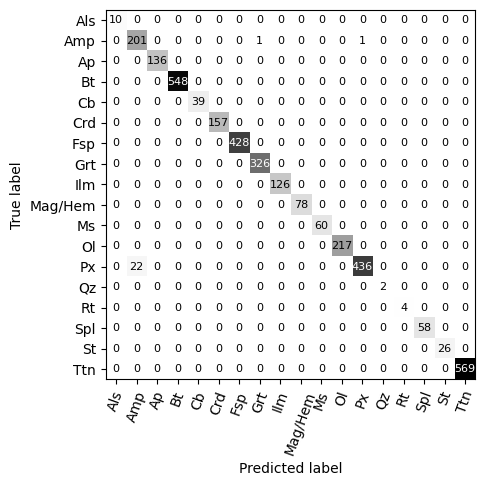

In [54]:
plt.figure(figsize=(5,5))
ConfusionMatrixDisplay.from_predictions(labeler.inverse_transform(test_target),labeler.inverse_transform(pred_label),
                                        text_kw={"size":8},im_kw={"cmap":"gray_r"},colorbar=False,xticks_rotation=70)

# C4

In [55]:
model = load("SVM_C4_5_components.mdl")
scaler = load("Scaler_SVM_C4_5_components.scl")
labeler = load("Labeler_SVM_C4_5_components.lbl")
pc = load("PCA_SVM_C4_5_components.pc")

data_test1 = data_test.copy()
data_test1 = normalize(data_test1[['SiO2','TiO2','Al2O3','FeO','MnO','MgO','CaO','Na2O','K2O','P2O5','CO2']])

data_test_scaled = scaler.transform(data_test1)
data_test_scaled = pc.transform(data_test_scaled)
test_target = labeler.transform(minerals)
pred_label = model.predict(data_test_scaled)
a = round(f1_score(test_target, pred_label, average=metrics,zero_division=0),4)*100
acc_table[0,3] = a
print("Overall: "+str(a))

labels = labeler.transform(minerals.unique())
labels1 = labeler.inverse_transform(labels)

for n,i in enumerate(labels1):
    data_test2 = scaler.transform(data_test1.loc[minerals==i,:])
    data_test2 = pc.transform(data_test2)
    minerals2 = labeler.transform(minerals.loc[minerals == i])
    pred_label2 = model.predict(data_test2)
    a = round(f1_score(minerals2, pred_label2, average=samplemetrics,zero_division=0),3)*100
    acc_table[n+1,3] = a
    print(labels1[n]+": "+str(round(a,2)))

data_mismatch = data_test.loc[test_target != pred_label,:]
minerals_mismatch = minerals.loc[test_target != pred_label]
data_mismatch = pd.concat([data_mismatch,minerals_mismatch],axis=1)
f1_c4 = f1_score(minerals, labeler.inverse_transform(pred_label),average=None)

Overall: 97.86
Amp: 96.1
Ap: 100.0
Bt: 99.8
Crd: 100.0
Fsp: 91.6
Grt: 100.0
Ilm: 100.0
Mag/Hem: 100.0
Ms: 95.0
Ol: 99.1
Px: 96.5
Spl: 100.0
St: 100.0
Ttn: 100.0
Als: 100.0
Cb: 97.4
Qz: 100.0
Rt: 100.0


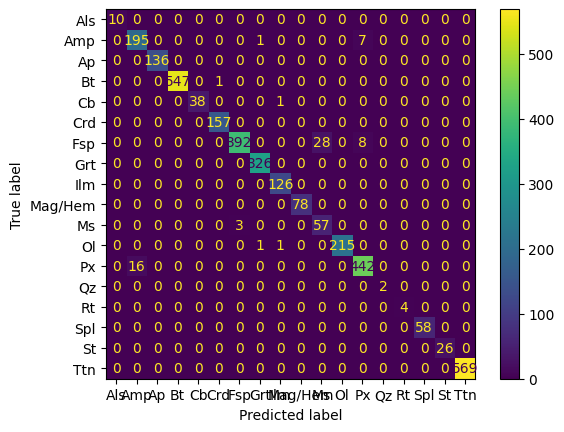

In [56]:
ConfusionMatrixDisplay.from_predictions(labeler.inverse_transform(test_target),labeler.inverse_transform(pred_label))

In [57]:
l=['Overall']
l.extend(list(minerals.unique()))
acc_table = pd.DataFrame(acc_table,
                          columns=["C1", "C2", "C3", "C4"],index=l)
acc_table.to_excel(r"F1-score Accuracy report for SVM.xlsx")

In [58]:
acc_table

,C1,C2,C3,C4
Overall,91.28,97.21,99.54,97.86
Amp,99.01,98.52,99.01,96.10
Ap,100.00,100.00,100.00,100.00
Bt,100.00,100.00,100.00,99.80
Crd,100.00,100.00,100.00,100.00
Fsp,84.35,85.05,100.00,91.60
Grt,99.69,100.00,100.00,100.00
Ilm,98.41,100.00,100.00,100.00
Mag/Hem,100.00,100.00,100.00,100.00
Ms,100.00,100.00,100.00,95.00
